# A.4 Policy Gradients - Reducing_Variance

Pedro Mauri Mtz - A01029143

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

In [7]:
params = np.array([0.0, 0.0])
evs = np.array([0.0, 0.0])
reward_aug = 0.0

lr = 0.01
epochs = 1000

reward_hist = []
params_hist = []
evs_hist = []

for i in range(epochs):

  r1 = np.random.choice([0, 1], p = [0.25, 0.75])
  r2 = np.random.choice([0, 1], p = [0.75, 0.25])

  action = np.random.choice([1, 2], p = softmax(params))

  reward = r1 if action == 1 else r2
  reward_hist.append(reward.copy())

  reward_avg = np.mean(reward_hist)

  grad = [0.0, 0.0]

  grad[action - 1] = 1

  evs[action - 1] += lr * (reward - evs[action - 1])
  evs_hist.append(evs.copy())

  reward_avg += lr * (reward - reward_avg)
  # params += lr * (grad - softmax(params)) * (reward - reward_avg)
  params += lr * (grad - softmax(params)) * (evs[action - 1])

  params_hist.append(params.copy())

reward_hist = np.array(reward_hist)
# print(reward_hist)
params_hist = np.array(params_hist)
# print(params_hist)
evs_hist = np.array(evs_hist)
# print(evs_hist)


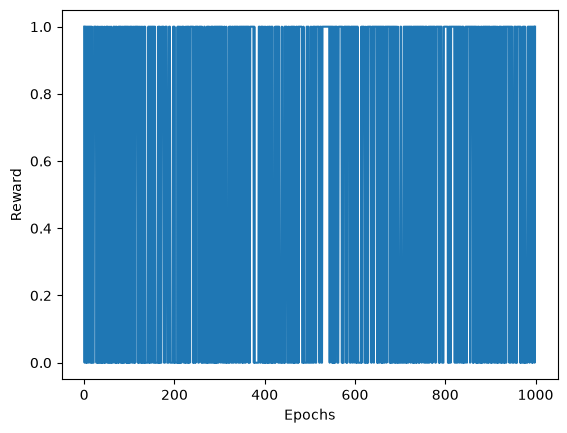

In [8]:
plt.plot(reward_hist)
plt.xlabel("Epochs")
plt.ylabel("Reward")
plt.show()

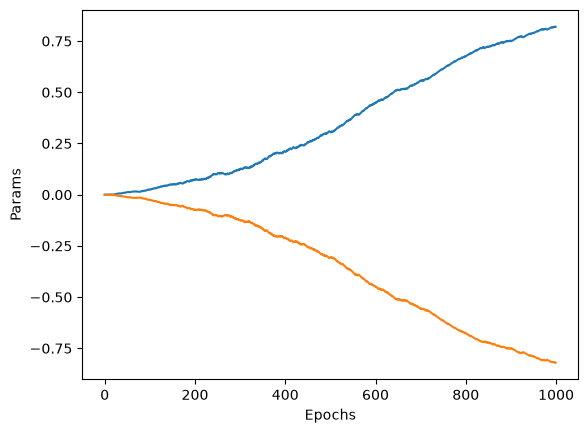

In [9]:
plt.plot(params_hist[:, 0], label = "Param 1")
plt.plot(params_hist[:, 1], label = "Param 2")
plt.xlabel("Epochs")
plt.ylabel("Params")
plt.show()

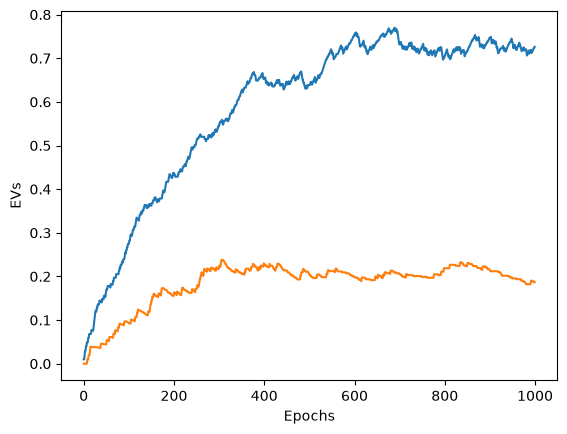

In [10]:
plt.plot(evs_hist[:, 0], label = "EV 1")
plt.plot(evs_hist[:, 1], label = "EV 2")
plt.xlabel("Epochs")
plt.ylabel("EVs")
plt.show()